# Prueba 5 - Ensamblado por stacking (meta-modelo)

Este notebook parte de la Prueba 4 (ensamblado por media) y prueba una alternativa:
en vez de promediar a mano las predicciones de los modelos base, se entrena un
**meta-modelo** que aprende, a partir de los valores reales, como combinar mejor
las salidas de los modelos base.

Pasos:

1. Carga los mismos modelos base que la Prueba 4 (single-target + familias
   multisalida, cada una como ensamblado interno de varios miembros).
2. Ejecuta el smoke test habitual sobre todo `eval.csv`.
3. Separa `eval.csv` en dos bloques: uno para **entrenar el meta-modelo**
   (meta-train) y otro para **evaluarlo** (meta-test / holdout), para no medir el
   meta-modelo con los mismos datos con los que se ha entrenado.
4. Para cada target, entrena un meta-modelo (Ridge) que recibe como entrada las
   predicciones de los modelos base y como salida el valor real.
5. Repite el smoke test sobre el meta-modelo, esta vez sobre el holdout.
6. Compara el error del meta-modelo frente a cada modelo base y frente al
   ensamblado simple por media (Prueba 4), todo medido sobre el mismo holdout.



## 1.- Configuración y carga de librerías

Misma configuración que la Prueba 4, pero en este caso se añaden las siguientes variables los meta-modelos:

- `META_TEST_SIZE`: proporcion de filas de `eval.csv` que se reservan como holdout
  para evaluar los meta-modelos (el resto se usa para entrenarlos).
- `META_MODEL_FACTORIES`: diccionario `{nombre: funcion_que_crea_el_modelo}`, con
  varios meta-modelos candidatos a probar en paralelo (Ridge, Lasso, ElasticNet,
  regresion lineal sin regularizar, y un Random Forest como candidato no lineal).
  Todos se entrenan y evaluan igual, y se comparan al final en la misma tabla. Se
  puede anadir o quitar candidatos libremente.

**Nota:** Si el tamaño general del dataset es bajo, hacer uso solamente de los datos de eval.csv. Los resultados de esta prueba de deben de tomar un uno o varios granos de sal, para tener datos realmente verídicos se recomendaría realizar una sub-prueba aún más grande. 
Si se obtienen más datos lo recomendable sería recurrir a CV (Validación Cruzada) o a hacer uso de un valor para el hold-out aún más grande.


In [1]:
import json
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Librerias cargadas correctamente...")


MODELS_DIR = Path("output/models")   
EVAL_PATH = Path("input/eval.csv")   

TARGETS_ORDER = [
    # Shannon
    'nematode_shannon_z',
    'macro_shannon_z',
    'earthworm_shannon_z',
    'orib_shannon_z',
    'meso_shannon_z',
    'coll_shannon_z',
    'bac_shannon_z',
    'fun_shannon_z',
    'euk_shannon_z',
    'oomy_shannon_z',
    'cerc_shannon_z',
    # Richness
    'macro_order_richness_z',
    'earthworm_richness_z',
    'orib_species_richness_z',
    'meso_species_richness_z',
    'coll_species_richness_z',
    'bac_asv_richness_z',
    'fun_asv_richness_z',
    'euk_asv_richness_z',
    'oomy_asv_richness_z',
    'cerc_asv_richness_z'
]

FEATURES_AUTORIZADAS = [
    'total_plant_cover_z',
    'clay_content_z',
    'silt_content_z',
    'sand_content_z',
    'aggregate_stability_z',
    'bulk_density_z',
    'soil_moisture_z',
    'as_z',
    'cu_z',
    'k_z',
    'mo_z',
    'ni_z',
    'p_z',
    'pb_z',
    'zn_z',
    'soil_ph_z',
    'plot_total_organic_c_z',
    'plot_total_n_z',
    'gee_temp_media_C_z',
    'gee_humedad_rel_pct_z',
    'gee_ndvi_verano_z',
    'dem_elevacion_m_z',
    'dem_pendiente_deg_z',
    'dem_orientacion_deg_z',
    'eu_clay_content_z',
    'eu_sand_content_z',
    'eu_silt_content_z',
    'eu_water_holding_capacity_z',
    'eu_cn_ratio_z',
    'eu_p_z',
    'eu_ph_z',
    'eu_as_z',
    'eu_organic_carbon_octop_z',
    'eu_zn_z'
]

TARGETS_TO_TEST = [
    # Shannon 
    'nematode_shannon_z',
    'macro_shannon_z',
    'earthworm_shannon_z',
    'orib_shannon_z',
    'meso_shannon_z',
    'coll_shannon_z',
    'bac_shannon_z',
    'fun_shannon_z',
    'euk_shannon_z',
    'oomy_shannon_z',
    'cerc_shannon_z',
    # Richness
    'macro_order_richness_z',
    'earthworm_richness_z',
    'orib_species_richness_z',
    'meso_species_richness_z',
    'coll_species_richness_z',
    'bac_asv_richness_z',
    'fun_asv_richness_z',
    'euk_asv_richness_z',
    'oomy_asv_richness_z',
    'cerc_asv_richness_z'
]

META_TEST_SIZE = 0.3  # proporcion de eval.csv reservada como holdout para evaluar los meta-modelos

# Varios meta-modelos candidatos, todos entrenados y evaluados igual. Anade/quita libremente.
META_MODEL_FACTORIES = {
    "Ridge":       lambda: Ridge(random_state=RANDOM_STATE),
    "Lasso":       lambda: Lasso(alpha=0.1, random_state=RANDOM_STATE),
    "ElasticNet":  lambda: ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=RANDOM_STATE),
    "Linear":      lambda: LinearRegression(),
    "RandomForest": lambda: RandomForestRegressor(n_estimators=200, max_depth=3, random_state=RANDOM_STATE),
}

assert all(t in TARGETS_ORDER for t in TARGETS_TO_TEST), (
    "Algun target de TARGETS_TO_TEST no esta en TARGETS_ORDER, revisa la configuracion..."
)


Librerias cargadas correctamente...


## 2.- Carga de `eval.csv`

In [2]:
eval_df = pd.read_csv(EVAL_PATH)

missing_features = [f for f in FEATURES_AUTORIZADAS if f not in eval_df.columns]
missing_targets = [t for t in TARGETS_ORDER if t not in eval_df.columns]
if missing_features:
    print(f"[AVISO] Faltan {len(missing_features)} features en eval.csv: {missing_features[:5]}...")
if missing_targets:
    print(f"[AVISO] Faltan {len(missing_targets)} targets en eval.csv: {missing_targets[:5]}...")

X_eval = eval_df[FEATURES_AUTORIZADAS]
y_eval = eval_df[TARGETS_ORDER]

print(f"eval.csv: {eval_df.shape[0]} filas, {eval_df.shape[1]} columnas")
print(f"X_eval: {X_eval.shape}  |  y_eval: {y_eval.shape}")


eval.csv: 65 filas, 71 columnas
X_eval: (65, 34)  |  y_eval: (65, 21)


## 3.- Definición y carga de los modelos base

Igual que en la Prueba 4: todos los modelos son ensamblados internos de varios
miembros entrenados por separado, **salvo Ridge, que es un unico modelo por target
(sin ensamblado)**. 

El resto de modelos, single-target (RF single-target, XGBoost single-target,
un ensamblado por target) y multisalida (RF, XGBoost, RegressorChain, MLP, MLP custom
loss, un ensamblado por familia), si son ensamblados: 5 miembros en todos salvo
RegressorChain, que tiene 10. 

`EnsembleWrapper` promedia internamente los miembros de cada ensamblado (para Ridge, con un unico miembro, no cambia el resultado), asi que a partir de aqui cada modelo base (single o multi) se trata como un unico modelo
consolidado.

Ridge, RF y XGBoost se guardan como `.pkl` (misma carga con `joblib.load`). El MLP y
el MLP con loss personalizada tienen sus propios pesos por miembro (`.pt`), pero el
config (`.pkl`) con la arquitectura usada al entrenar es **unico por familia** (no uno
por miembro).


In [3]:
def load_sklearn(path):
    return joblib.load(path)


def load_mlp_member(weights_path, config_path):
    import torch
    import torch.nn as nn

    config = joblib.load(config_path)

    def _cfg_get(key, default):
        # El config puede venir como dict o como un objeto (p.ej. dataclass/Namespace).
        if isinstance(config, dict):
            return config.get(key, default)
        return getattr(config, key, default)

    class GenericMLP(nn.Module):
        def __init__(self, input_dim, hidden_dims, output_dim, dropout=0.0):
            super().__init__()
            layers = []
            prev_dim = input_dim
            for h in hidden_dims:
                layers.append(nn.Linear(prev_dim, h))
                layers.append(nn.ReLU())
                if dropout > 0:
                    layers.append(nn.Dropout(dropout))
                prev_dim = h
            layers.append(nn.Linear(prev_dim, output_dim))
            self.red = nn.Sequential(*layers)

        def forward(self, x):
            return self.red(x)

        def predict(self, X):
            self.eval()
            with torch.no_grad():
                X_t = torch.as_tensor(np.asarray(X), dtype=torch.float32)
                return self.red(X_t).numpy()

    model = GenericMLP(
        input_dim=_cfg_get("input_dim", len(FEATURES_AUTORIZADAS)),
        hidden_dims=_cfg_get("hidden", [64, 32]),
        output_dim=_cfg_get("output_dim", len(TARGETS_ORDER)),
        dropout=_cfg_get("dropout", 0.0),
    )
    state_dict = torch.load(Path(weights_path), map_location="cpu")
    model.load_state_dict(state_dict)
    model.eval()
    return model


class EnsembleWrapper:
    '''Modelo (single-target o multisalida) guardado como ensamblado de varios miembros
    entrenados por separado. predict() promedia la prediccion de todos los miembros
    disponibles. Si falta algun miembro (fichero no encontrado, error de carga),
    simplemente se promedia con los que si se cargaron.

    kind="single": cada miembro predice directamente el target -> se promedian tal cual.
    kind="multi": cada miembro predice todos los targets a la vez -> primero se
    selecciona la columna del target pedido en cada miembro y despues se promedia.
    '''

    def __init__(self, key, label, members, kind, targets_order=None):
        self.key = key
        self.label = label
        self.members = members
        self.kind = kind
        self.targets_order = targets_order

    def predict(self, X, target=None):
        member_preds = []
        for model in self.members:
            preds = np.asarray(model.predict(X))
            if self.kind == "multi":
                if preds.ndim == 1:
                    preds = preds.reshape(-1, 1)
                idx = self.targets_order.index(target)
                preds = preds[:, idx]
            else:
                preds = preds.reshape(-1)
            member_preds.append(preds)
        return np.mean(np.column_stack(member_preds), axis=1)


def load_ensemble_members(loader, path_template, n_members, loader_kwargs=None, **template_kwargs):
    '''Carga los n_members ficheros de un ensamblado, tolerando fallos parciales.
    loader_kwargs son argumentos fijos que se pasan a loader() en cada miembro (p.ej.
    un config compartido por toda la familia, en vez de uno por miembro).
    Devuelve (members, errors), donde errors es una lista de (indice, tipo_error, mensaje).
    '''
    loader_kwargs = loader_kwargs or {}
    members = []
    errors = []
    for i in range(n_members):
        path = Path(path_template.format(i=i, **template_kwargs))
        try:
            members.append(loader(path, **loader_kwargs))
        except Exception as e:
            errors.append((i, type(e).__name__, str(e)))
    return members, errors


SINGLE_MODEL_CONFIGS = [
    {"key": "ridge",      "label": "Ridge",                 "loader": load_sklearn, "path_template": str(MODELS_DIR / "reg/ridge_prod_{target}.pkl"),     "n_members": 1},
    {"key": "rf_single",  "label": "RF single-target",      "loader": load_sklearn, "path_template": str(MODELS_DIR / "rf/rf_prod_{target}_m{i}.pkl"),     "n_members": 5},
    {"key": "xgb_single", "label": "XGBoost single-target", "loader": load_sklearn, "path_template": str(MODELS_DIR / "xgb/xgb_prod_{target}_exp{i}.pkl"),   "n_members": 5},
]

MULTI_MODEL_CONFIGS = [
    {"key": "rf_multi",   "label": "RF multisalida",      "loader": load_sklearn,     "path_template": str(MODELS_DIR / "rf_multi/rf_multi_m{i}.pkl"),    "n_members": 5},
    {"key": "xgb_multi",  "label": "XGBoost multisalida", "loader": load_sklearn,     "path_template": str(MODELS_DIR / "xgb_multi/xgb_multi_exp{i}.pkl"), "n_members": 5},
    {"key": "regchain",   "label": "RegressorChain",      "loader": load_sklearn,     "path_template": str(MODELS_DIR / "chain/chain_{i}.pkl"),       "n_members": 10},
    {"key": "mlp_multi",  "label": "MLP multisalida",     "loader": load_mlp_member,  "path_template": str(MODELS_DIR / "mlp/mlp_prod_{i}.pt"),         "n_members": 5,
     "loader_kwargs": {"config_path": str(MODELS_DIR / "mlp/mlp_config.pkl")}},
    {"key": "mlp_custom", "label": "MLP custom loss",     "loader": load_mlp_member,  "path_template": str(MODELS_DIR / "mlp_custom/mlp_custom_{i}.pt"),  "n_members": 5,
     "loader_kwargs": {"config_path": str(MODELS_DIR / "mlp_custom/mlp_custom_config.pkl")}},
]

loaded_single = {}   # (key, target) -> EnsembleWrapper
loaded_multi = {}    # key -> EnsembleWrapper

for cfg in SINGLE_MODEL_CONFIGS:
    for target in TARGETS_TO_TEST:
        members, errors = load_ensemble_members(cfg["loader"], cfg["path_template"], cfg["n_members"],
                                                  loader_kwargs=cfg.get("loader_kwargs"), target=target)
        if members:
            loaded_single[(cfg["key"], target)] = EnsembleWrapper(cfg["key"], cfg["label"], members, kind="single")
            print(f"OK    {cfg['label']:22s} [{target}] cargado ({len(members)}/{cfg['n_members']} miembros)")
            if errors:
                print(f"      [AVISO] {len(errors)} miembro(s) no disponible(s), se promedia solo con el resto -> primer error: {errors[0][1]}: {errors[0][2]}")
        else:
            print(f"FALLO {cfg['label']:22s} [{target}] omitido -> no se cargo ningun miembro (0/{cfg['n_members']})")
            if errors:
                print(f"      -> primer error: {errors[0][1]}: {errors[0][2]}")

for cfg in MULTI_MODEL_CONFIGS:
    members, errors = load_ensemble_members(cfg["loader"], cfg["path_template"], cfg["n_members"],
                                             loader_kwargs=cfg.get("loader_kwargs"))
    if members:
        loaded_multi[cfg["key"]] = EnsembleWrapper(cfg["key"], cfg["label"], members, kind="multi", targets_order=TARGETS_ORDER)
        print(f"OK    {cfg['label']:22s} cargado ({len(members)}/{cfg['n_members']} miembros)")
        if errors:
            print(f"      [AVISO] {len(errors)} miembro(s) no disponible(s), se promedia solo con el resto -> primer error: {errors[0][1]}: {errors[0][2]}")
    else:
        print(f"FALLO {cfg['label']:22s} omitido -> no se cargo ningun miembro (0/{cfg['n_members']})")
        if errors:
            print(f"      -> primer error: {errors[0][1]}: {errors[0][2]}")

print(f"\nModelos base disponibles: {len(loaded_single)} single-target (por target) + {len(loaded_multi)} familias multisalida")


OK    Ridge                  [nematode_shannon_z] cargado (1/1 miembros)
OK    Ridge                  [macro_shannon_z] cargado (1/1 miembros)
OK    Ridge                  [earthworm_shannon_z] cargado (1/1 miembros)
OK    Ridge                  [orib_shannon_z] cargado (1/1 miembros)
OK    Ridge                  [meso_shannon_z] cargado (1/1 miembros)
OK    Ridge                  [coll_shannon_z] cargado (1/1 miembros)
OK    Ridge                  [bac_shannon_z] cargado (1/1 miembros)
OK    Ridge                  [fun_shannon_z] cargado (1/1 miembros)
OK    Ridge                  [euk_shannon_z] cargado (1/1 miembros)
OK    Ridge                  [oomy_shannon_z] cargado (1/1 miembros)
OK    Ridge                  [cerc_shannon_z] cargado (1/1 miembros)
OK    Ridge                  [macro_order_richness_z] cargado (1/1 miembros)
OK    Ridge                  [earthworm_richness_z] cargado (1/1 miembros)
OK    Ridge                  [orib_species_richness_z] cargado (1/1 miembros)
OK  

## 4.- Smoke test sobre `eval.csv` completo

Igual que en la Prueba 4: se predice una unica vez sobre todo `eval.csv` y se
reutilizan las predicciones despues, tanto para entrenar como para evaluar el
meta-modelo (respetando la particion train/holdout de la seccion 5).


In [4]:
def smoke_test(wrapper, X, y_true, target):
    try:
        preds = wrapper.predict(X, target=target)
    except Exception as e:
        print(f"[SMOKE TEST] {wrapper.label:22s} | {target:22s} | ERROR al predecir -> {type(e).__name__}: {e}")
        return None

    preds = np.asarray(preds, dtype=float).reshape(-1)
    shape_ok = preds.shape[0] == len(X)
    n_nan = int(np.isnan(preds).sum())
    n_inf = int(np.isinf(preds).sum())
    ok = shape_ok and n_nan == 0 and n_inf == 0
    r2 = r2_score(y_true, preds) if ok else float("nan")
    status = "OK" if ok else "REVISAR"
    print(f"[SMOKE TEST] {wrapper.label:22s} | {target:22s} | filas={len(preds):5d} | "
          f"NaN={n_nan} | Inf={n_inf} | R2={r2: .4f} | {status}")
    return preds if ok else None


# predictions[target][label] = np.array de predicciones sobre TODO eval.csv (solo si paso el smoke test)
predictions = {t: {} for t in TARGETS_TO_TEST}

for target in TARGETS_TO_TEST:
    y_true_t = y_eval[target].values
    print(f"\n--- {target} ---")

    for (key, t), wrapper in loaded_single.items():
        if t != target:
            continue
        preds = smoke_test(wrapper, X_eval, y_true_t, target)
        if preds is not None:
            predictions[target][wrapper.label] = preds

    for key, wrapper in loaded_multi.items():
        preds = smoke_test(wrapper, X_eval, y_true_t, target)
        if preds is not None:
            predictions[target][wrapper.label] = preds



--- nematode_shannon_z ---
[SMOKE TEST] Ridge                  | nematode_shannon_z     | filas=   65 | NaN=0 | Inf=0 | R2= 0.0112 | OK
[SMOKE TEST] RF single-target       | nematode_shannon_z     | filas=   65 | NaN=0 | Inf=0 | R2= 0.1366 | OK
[SMOKE TEST] XGBoost single-target  | nematode_shannon_z     | filas=   65 | NaN=0 | Inf=0 | R2= 0.1637 | OK
[SMOKE TEST] RF multisalida         | nematode_shannon_z     | filas=   65 | NaN=0 | Inf=0 | R2= 0.1545 | OK
[SMOKE TEST] XGBoost multisalida    | nematode_shannon_z     | filas=   65 | NaN=0 | Inf=0 | R2= 0.2228 | OK
[SMOKE TEST] RegressorChain         | nematode_shannon_z     | filas=   65 | NaN=0 | Inf=0 | R2= 0.1525 | OK
[SMOKE TEST] MLP multisalida        | nematode_shannon_z     | filas=   65 | NaN=0 | Inf=0 | R2= 0.0829 | OK
[SMOKE TEST] MLP custom loss        | nematode_shannon_z     | filas=   65 | NaN=0 | Inf=0 | R2= 0.0668 | OK

--- macro_shannon_z ---
[SMOKE TEST] Ridge                  | macro_shannon_z        | filas=   65 

## 5.- Particion meta-train / meta-holdout

Se separan las filas de `eval.csv` en dos bloques usando los mismos indices para
todos los targets: uno para entrenar el meta-modelo y otro (holdout) para evaluarlo
despues, sin que haya visto esas filas durante el entrenamiento.


In [11]:
idx_all = np.arange(len(eval_df))
idx_train, idx_holdout = train_test_split(idx_all, test_size=META_TEST_SIZE, random_state=RANDOM_STATE)

print(f"Filas totales en eval.csv: {len(idx_all)}")
print(f"Filas para entrenar el meta-modelo (meta-train):  {len(idx_train)}")
print(f"Filas para evaluar el meta-modelo (holdout):      {len(idx_holdout)}")

Filas totales en eval.csv: 65
Filas para entrenar el meta-modelo (meta-train):  45
Filas para evaluar el meta-modelo (holdout):      20


## 6.- Entrenamiento de los meta-modelos por target

Para cada target y cada candidato de `META_MODEL_FACTORIES`, la entrada es la matriz
de predicciones de todos los modelos base disponibles (una columna por modelo) sobre
las filas de meta-train, y la salida es el valor real de ese target en esas mismas
filas.


In [6]:
meta_models = {}       # target -> {"model_labels": [...], "models": {nombre_meta: modelo_entrenado}}
stacked_features = {}  # target -> matriz (n_filas_eval x n_modelos_base), mismo orden que eval_df

for target in TARGETS_TO_TEST:
    model_labels = list(predictions[target].keys())
    if not model_labels:
        print(f"[AVISO] {target}: no hay modelos base disponibles, no se pueden entrenar los meta-modelos.")
        continue

    X_meta = np.column_stack([predictions[target][lbl] for lbl in model_labels])
    stacked_features[target] = X_meta

    y_target = y_eval[target].values
    X_meta_train = X_meta[idx_train]
    y_meta_train = y_target[idx_train]

    trained = {}
    for meta_name, factory in META_MODEL_FACTORIES.items():
        meta_model = factory()
        meta_model.fit(X_meta_train, y_meta_train)
        trained[meta_name] = meta_model

    meta_models[target] = {"model_labels": model_labels, "models": trained}
    print(f"{target}: {len(trained)} meta-modelos entrenados con {len(model_labels)} modelos base -> {list(trained)}")


nematode_shannon_z: 5 meta-modelos entrenados con 8 modelos base -> ['Ridge', 'Lasso', 'ElasticNet', 'Linear', 'RandomForest']
macro_shannon_z: 5 meta-modelos entrenados con 8 modelos base -> ['Ridge', 'Lasso', 'ElasticNet', 'Linear', 'RandomForest']
earthworm_shannon_z: 5 meta-modelos entrenados con 8 modelos base -> ['Ridge', 'Lasso', 'ElasticNet', 'Linear', 'RandomForest']
orib_shannon_z: 5 meta-modelos entrenados con 8 modelos base -> ['Ridge', 'Lasso', 'ElasticNet', 'Linear', 'RandomForest']
meso_shannon_z: 5 meta-modelos entrenados con 8 modelos base -> ['Ridge', 'Lasso', 'ElasticNet', 'Linear', 'RandomForest']
coll_shannon_z: 5 meta-modelos entrenados con 8 modelos base -> ['Ridge', 'Lasso', 'ElasticNet', 'Linear', 'RandomForest']
bac_shannon_z: 5 meta-modelos entrenados con 8 modelos base -> ['Ridge', 'Lasso', 'ElasticNet', 'Linear', 'RandomForest']
fun_shannon_z: 5 meta-modelos entrenados con 8 modelos base -> ['Ridge', 'Lasso', 'ElasticNet', 'Linear', 'RandomForest']
euk_shan

## 7.- Smoke test de los meta-modelos sobre el holdout

Mismas comprobaciones que antes (sin error, sin NaN/Inf, tamano correcto), aplicadas
a cada meta-modelo sobre las filas de holdout que no ha visto en el entrenamiento.
Tambien se guardan aqui las predicciones de cada modelo base y del ensamblado simple
por media, recortadas al mismo holdout, para poder comparar todo en igualdad de
condiciones en la seccion 8.


In [7]:
holdout_predictions = {t: {} for t in TARGETS_TO_TEST}

for target in TARGETS_TO_TEST:
    if target not in meta_models:
        continue

    y_true_holdout = y_eval[target].values[idx_holdout]
    print(f"\n--- {target} (holdout, {len(idx_holdout)} filas) ---")

    # Modelos base, recortados al holdout
    for label in meta_models[target]["model_labels"]:
        preds_full = predictions[target][label]
        preds_holdout = np.asarray(preds_full, dtype=float)[idx_holdout]
        n_nan = int(np.isnan(preds_holdout).sum())
        n_inf = int(np.isinf(preds_holdout).sum())
        ok = n_nan == 0 and n_inf == 0
        r2 = r2_score(y_true_holdout, preds_holdout) if ok else float("nan")
        status = "OK" if ok else "REVISAR"
        print(f"[SMOKE TEST] {label:22s} | filas={len(preds_holdout):5d} | NaN={n_nan} | Inf={n_inf} | R2={r2: .4f} | {status}")
        if ok:
            holdout_predictions[target][label] = preds_holdout

    # Ensamblado simple por media, calculado solo con las filas del holdout
    model_labels = meta_models[target]["model_labels"]
    stacked_holdout = np.column_stack([predictions[target][lbl] for lbl in model_labels])[idx_holdout]
    mean_ensemble_holdout = stacked_holdout.mean(axis=1)
    holdout_predictions[target]["Ensamblado (media)"] = mean_ensemble_holdout

    # Cada meta-modelo candidato
    X_meta_holdout = stacked_features[target][idx_holdout]
    for meta_name, meta_model in meta_models[target]["models"].items():
        label = f"Meta-modelo ({meta_name})"
        try:
            meta_preds = np.asarray(meta_model.predict(X_meta_holdout), dtype=float).reshape(-1)
            n_nan = int(np.isnan(meta_preds).sum())
            n_inf = int(np.isinf(meta_preds).sum())
            ok = meta_preds.shape[0] == len(idx_holdout) and n_nan == 0 and n_inf == 0
            r2 = r2_score(y_true_holdout, meta_preds) if ok else float("nan")
            status = "OK" if ok else "REVISAR"
            print(f"[SMOKE TEST] {label:22s} | filas={len(meta_preds):5d} | NaN={n_nan} | Inf={n_inf} | R2={r2: .4f} | {status}")
            if ok:
                holdout_predictions[target][label] = meta_preds
        except Exception as e:
            print(f"[SMOKE TEST] {label:22s} | ERROR al predecir -> {type(e).__name__}: {e}")



--- nematode_shannon_z (holdout, 20 filas) ---
[SMOKE TEST] Ridge                  | filas=   20 | NaN=0 | Inf=0 | R2=-0.0695 | OK
[SMOKE TEST] RF single-target       | filas=   20 | NaN=0 | Inf=0 | R2= 0.1074 | OK
[SMOKE TEST] XGBoost single-target  | filas=   20 | NaN=0 | Inf=0 | R2= 0.1346 | OK
[SMOKE TEST] RF multisalida         | filas=   20 | NaN=0 | Inf=0 | R2= 0.0853 | OK
[SMOKE TEST] XGBoost multisalida    | filas=   20 | NaN=0 | Inf=0 | R2= 0.2808 | OK
[SMOKE TEST] RegressorChain         | filas=   20 | NaN=0 | Inf=0 | R2= 0.1921 | OK
[SMOKE TEST] MLP multisalida        | filas=   20 | NaN=0 | Inf=0 | R2= 0.0073 | OK
[SMOKE TEST] MLP custom loss        | filas=   20 | NaN=0 | Inf=0 | R2= 0.0617 | OK
[SMOKE TEST] Meta-modelo (Ridge)    | filas=   20 | NaN=0 | Inf=0 | R2= 0.2550 | OK
[SMOKE TEST] Meta-modelo (Lasso)    | filas=   20 | NaN=0 | Inf=0 | R2= 0.2238 | OK
[SMOKE TEST] Meta-modelo (ElasticNet) | filas=   20 | NaN=0 | Inf=0 | R2= 0.2206 | OK
[SMOKE TEST] Meta-modelo (

## 8.- Comparativa: modelos individuales vs. ensamblado por media vs. meta-modelo

Todas las metricas de esta tabla se calculan sobre el mismo holdout, para que la
comparacion entre modelos base, ensamblado simple y meta-modelo sea justa.


In [8]:
rows = []
for target in TARGETS_TO_TEST:
    if target not in meta_models:
        continue
    y_true_holdout = y_eval[target].values[idx_holdout]
    for label, preds in holdout_predictions[target].items():
        rmse = mean_squared_error(y_true_holdout, preds) ** 0.5
        rows.append({
            "target": target,
            "modelo": label,
            "R2": r2_score(y_true_holdout, preds),
            "RMSE": rmse,
            "MAE": mean_absolute_error(y_true_holdout, preds),
            "tipo": "meta-modelo" if label.startswith("Meta-modelo (") else ("ensamblado media" if label == "Ensamblado (media)" else "individual"),
        })

if not rows:
    print("[AVISO] No hay predicciones de holdout disponibles todavia. "
          "Revisa que los modelos base se hayan cargado (seccion 3), que el smoke test "
          "haya pasado (seccion 4) y que los meta-modelos se hayan entrenado (seccion 6).")
    results_df = pd.DataFrame(columns=["target", "modelo", "R2", "RMSE", "MAE", "tipo"])
else:
    results_df = pd.DataFrame(rows).sort_values(["target", "R2"], ascending=[True, False]).reset_index(drop=True)

results_df


,target,modelo,R2,RMSE,MAE,tipo
0,bac_asv_richness_z,Meta-modelo (ElasticNet),0.026856,0.808248,0.594321,meta-modelo
1,bac_asv_richness_z,Meta-modelo (Lasso),0.018270,0.811806,0.617058,meta-modelo
2,bac_asv_richness_z,Meta-modelo (Ridge),-0.022657,0.828555,0.593747,meta-modelo
3,bac_asv_richness_z,XGBoost multisalida,-0.089010,0.855012,0.627395,individual
4,bac_asv_richness_z,XGBoost single-target,-0.090581,0.855628,0.626837,individual
...,...,...,...,...,...,...
289,orib_species_richness_z,Meta-modelo (Lasso),-0.315931,1.028440,0.734192,meta-modelo
290,orib_species_richness_z,Meta-modelo (Linear),-0.339535,1.037623,0.744418,meta-modelo
291,orib_species_richness_z,Meta-modelo (ElasticNet),-0.358041,1.044765,0.748035,meta-modelo
292,orib_species_richness_z,Meta-modelo (Ridge),-0.444938,1.077673,0.771895,meta-modelo


## 8.1.- Resumen agregado por target

Con muchos targets a la vez, `results_df` tiene demasiadas filas para leerla a ojo.
Esta tabla se queda con una fila por target: el mejor modelo individual, el mejor
meta-modelo (o ensamblado por media), cual de los dos gana, y si el mejor R2 de ese
target es positivo (es decir, si hay alguna señal predictiva real) o no.

**R2 <= 0 significa que ni el mejor modelo hace mejor que predecir siempre la media**
-- en esos targets el problema no es que meta-modelo usar, sino que los modelos base
no tienen señal util que aprender a combinar. En targets sin señal, ademas, conviene
fijarse en si los meta-modelos quedan claramente peor que el mejor individual (mas
sobreajuste al meta-train cuanto menos señal real hay para aprender).

In [9]:
if results_df.empty:
    print("[AVISO] results_df esta vacio. Ejecuta primero las secciones 3-8.")
    summary_df = pd.DataFrame(columns=[
        "target", "mejor_individual", "R2_mejor_individual",
        "mejor_no_individual", "R2_mejor_no_individual", "gana_no_individual", "mejor_R2_global",
    ])
else:
    summary_rows = []
    for target in results_df["target"].unique():
        sub = results_df[results_df["target"] == target]

        individuales = sub[sub["tipo"] == "individual"].sort_values("R2", ascending=False)
        no_individuales = sub[sub["tipo"] != "individual"].sort_values("R2", ascending=False)

        mejor_individual = individuales.iloc[0] if not individuales.empty else None
        mejor_no_individual = no_individuales.iloc[0] if not no_individuales.empty else None

        r2_individual = mejor_individual["R2"] if mejor_individual is not None else float("-inf")
        r2_no_individual = mejor_no_individual["R2"] if mejor_no_individual is not None else float("-inf")

        summary_rows.append({
            "target": target,
            "mejor_individual": mejor_individual["modelo"] if mejor_individual is not None else None,
            "R2_mejor_individual": r2_individual,
            "mejor_no_individual": mejor_no_individual["modelo"] if mejor_no_individual is not None else None,
            "R2_mejor_no_individual": r2_no_individual,
            "gana_no_individual": bool(r2_no_individual > r2_individual),
            "mejor_R2_global": max(r2_individual, r2_no_individual),
        })

    summary_df = pd.DataFrame(summary_rows).sort_values("mejor_R2_global", ascending=False).reset_index(drop=True)

    n_targets = len(summary_df)
    n_gana_no_individual = int(summary_df["gana_no_individual"].sum())
    n_r2_positivo = int((summary_df["mejor_R2_global"] > 0).sum())

    print(f"Targets evaluados: {n_targets}")
    print(f"Targets donde algun meta-modelo/ensamblado supera al mejor individual: "
          f"{n_gana_no_individual}/{n_targets} ({n_gana_no_individual / n_targets:.0%})")
    print(f"Targets con señal predictiva real (mejor R2 > 0): "
          f"{n_r2_positivo}/{n_targets} ({n_r2_positivo / n_targets:.0%})")
    print(f"Targets sin señal predictiva (mejor R2 <= 0, ningun modelo le gana a la media): "
          f"{n_targets - n_r2_positivo}")

summary_df

Targets evaluados: 21
Targets donde algun meta-modelo/ensamblado supera al mejor individual: 9/21 (43%)
Targets con señal predictiva real (mejor R2 > 0): 18/21 (86%)
Targets sin señal predictiva (mejor R2 <= 0, ningun modelo le gana a la media): 3


,target,mejor_individual,R2_mejor_individual,mejor_no_individual,R2_mejor_no_individual,gana_no_individual,mejor_R2_global
0,earthworm_richness_z,XGBoost multisalida,0.508708,Meta-modelo (Ridge),0.529900,True,0.529900
1,coll_species_richness_z,RF multisalida,-0.069098,Meta-modelo (RandomForest),0.526353,True,0.526353
2,macro_order_richness_z,XGBoost multisalida,0.509020,Ensamblado (media),0.402584,False,0.509020
3,cerc_asv_richness_z,XGBoost multisalida,0.404936,Meta-modelo (RandomForest),0.474221,True,0.474221
4,macro_shannon_z,RegressorChain,0.404080,Ensamblado (media),0.303551,False,0.404080
5,coll_shannon_z,RF multisalida,-0.058985,Meta-modelo (Linear),0.392849,True,0.392849
6,earthworm_shannon_z,RegressorChain,0.374996,Meta-modelo (RandomForest),0.341104,False,0.374996
7,oomy_asv_richness_z,RegressorChain,0.304284,Meta-modelo (Ridge),0.266410,False,0.304284
8,nematode_shannon_z,XGBoost multisalida,0.280802,Meta-modelo (Ridge),0.255040,False,0.280802
9,euk_asv_richness_z,RF single-target,0.219539,Meta-modelo (ElasticNet),0.209901,False,0.219539


## 9.- Visualización

Barras de R2 por modelo y target sobre el holdout. Los meta-modelos y el ensamblado
por media se resaltan con borde negro para distinguirlos de los modelos base.


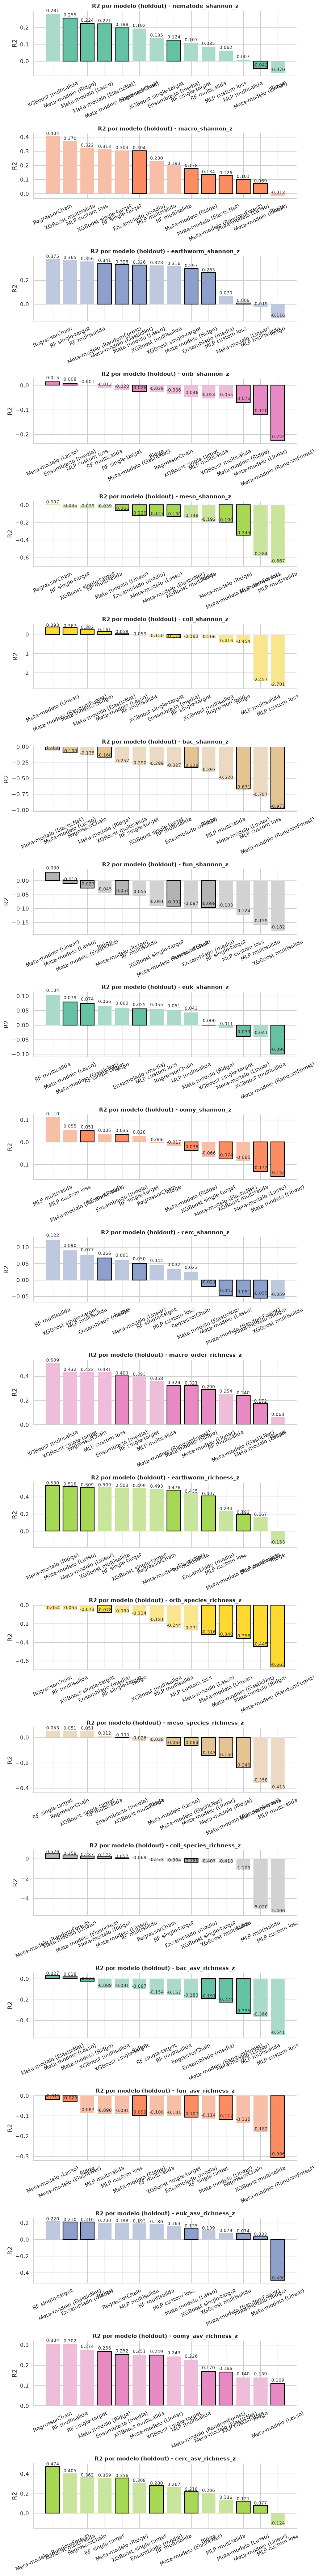

In [10]:
if results_df.empty:
    print("[AVISO] results_df esta vacio, no hay nada que graficar. Ejecuta primero las secciones 3-8.")
else:
    targets_present = [t for t in TARGETS_TO_TEST if t in results_df["target"].unique()]
    palette = sns.color_palette("Set2", n_colors=max(len(targets_present), 3))
    TARGET_COLORS = dict(zip(targets_present, palette))

    fig, axes = plt.subplots(len(targets_present), 1, figsize=(9, 3.4 * len(targets_present)), squeeze=False)

    for ax, target in zip(axes[:, 0], targets_present):
        sub = results_df[results_df["target"] == target].sort_values("R2", ascending=False)
        base_color = TARGET_COLORS[target]
        is_highlighted = sub["tipo"] != "individual"
        colors = [base_color if h else sns.light_palette(base_color, n_colors=3)[1] for h in is_highlighted]
        edgecolors = ["black" if h else "none" for h in is_highlighted]
        linewidths = [1.6 if h else 0 for h in is_highlighted]

        bars = ax.bar(sub["modelo"], sub["R2"], color=colors, edgecolor=edgecolors, linewidth=linewidths)
        for bar, r2 in zip(bars, sub["R2"]):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, f"{r2:.3f}",
                    ha="center", fontsize=8.5, color="#333333")
        ax.set_title(f"R2 por modelo (holdout) - {target}", fontsize=11, fontweight="bold")
        ax.set_ylabel("R2")
        ax.tick_params(axis="x", rotation=25)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    fig.tight_layout()
    fig.savefig("output/r2_comparativa_con_modelos.png", dpi=300, bbox_inches="tight")
    plt.show()


## 10. Conclusiones

[COMPLETAR tras ejecutar con los modelos y `eval.csv` reales]

- ¿Algun meta-modelo mejora el R2 en el holdout respecto al ensamblado simple por
  media y respecto al mejor modelo individual, en alguno de los targets probados?
- ¿Es siempre el mismo meta-modelo el que gana en los distintos targets, o cambia
  segun el target? Si Ridge/Lasso/ElasticNet (regularizados) generalizan mejor que
  Linear/RandomForest (mas parametros libres) en el target con menos datos o mas
  ruido, es una señal de sobreajuste en los candidatos menos regularizados.
- ¿La mejora (si la hay) es consistente entre targets o depende mucho de cual se pruebe?
- Dado que el holdout es pequeno, ¿los resultados parecen estables o muy sensibles al
  `RANDOM_STATE` usado en el `train_test_split`? Se puede repetir el notebook con otras
  semillas para comprobarlo, target a target y meta-modelo a meta-modelo.
- ¿Compensa la complejidad extra de mantener y versionar un meta-modelo (ademas de los
  modelos base) frente a quedarse con el ensamblado simple por media o con el mejor
  modelo individual por target?
- Si se dispone de mas datos en el futuro, ¿merece la pena repetir este notebook con
  validacion cruzada (predicciones out-of-fold) en vez de un unico split train/holdout,
  para reducir el riesgo de sobreajustar los meta-modelos a una particion concreta?
